In [2]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.metrics import silhouette_score, silhouette_samples, confusion_matrix


from utils import (
    scaling,
    plot_dendrogram,
    plot_2d_with_classes,
    visualize_dimensionality_reduction
)


from clustering import(
    plot_silhouette
)

In [3]:
dataset = pd.read_csv('../data/final_dataset.csv', index_col= 0)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,has_children,year_first_transaction,years_tenure,...,perc_alcohol_drinks,perc_spend_hygiene,latitude,longitude,total_trips,total_items_bought,average_basket_size,max_basket_size,min_basket_size,unique_products_bought
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,1,2020,6,...,0.354000,0.029693,38.794428,-9.215739,2,21,10.5,11,10,21
4,Glenda Bauman,female,51,Bsc,1,0,1,1,2013,13,...,0.151274,0.092918,38.751711,-9.179611,2,24,12.0,12,12,20
5,Antonio Campbell,male,55,Msc,0,0,0,0,2005,21,...,0.538813,0.032607,38.780678,-9.160656,1,8,8.0,8,8,8
7,John Kelling,male,44,Unknown,0,0,0,0,2021,5,...,0.599471,0.032437,38.739548,-9.148679,1,4,4.0,4,4,4
9,Nadine Garcia,female,58,Msc,1,1,2,1,2011,15,...,0.472042,0.024424,38.735577,-9.172423,2,20,10.0,14,6,20


In [4]:

dataset.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'total_children', 'has_children',
       'year_first_transaction', 'years_tenure', 'distinct_stores_visited',
       'number_complaints', 'typical_hour', 'time_of_day',
       'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'total_spend', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_petfood',
       'perc_spend_tech_entertainment', 'perc_spend_groceries',
       'perc_alcohol_drinks', 'perc_spend_hygiene', 'latitude', 'longitude'

In [5]:
'''
features_para_treino = [
    'customer_age',
    'years_tenure',
    'number_complaints', 
    'total_children',
    'percentage_of_products_bought_promotion', 
    'perc_spend_vegetables', 
    'perc_spend_meat_fish', 
    'perc_spend_petfood', 
    'perc_spend_tech_entertainment',
    'distinct_stores_visited']
'''
features = ['customer_age',
    'number_complaints',
    'total_children',
    'percentage_of_products_bought_promotion',
    'perc_spend_vegetables',
    'perc_spend_meat_fish',
    'perc_alcohol_drinks',
    'perc_spend_petfood',
    'perc_spend_tech_entertainment',
    'years_tenure'
]
X = dataset[features].copy()

# Fazer o StandardScaler APENAS nestas variávei

X = dataset[features].copy()
X.columns

Index(['customer_age', 'number_complaints', 'total_children',
       'percentage_of_products_bought_promotion', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_alcohol_drinks', 'perc_spend_petfood',
       'perc_spend_tech_entertainment', 'years_tenure'],
      dtype='str')

In [6]:

# Aplica log1p (log(x+1)) a todas as spend features ANTES do scaling
lifetime_spend_cols = [col for col in features if 'lifetime_spend' in col]


X_log = X.copy()
X_log[lifetime_spend_cols] = np.log1p(X_log[lifetime_spend_cols])

# Depois faz o scaling normalmente
X_scaled = scaling(X_log)

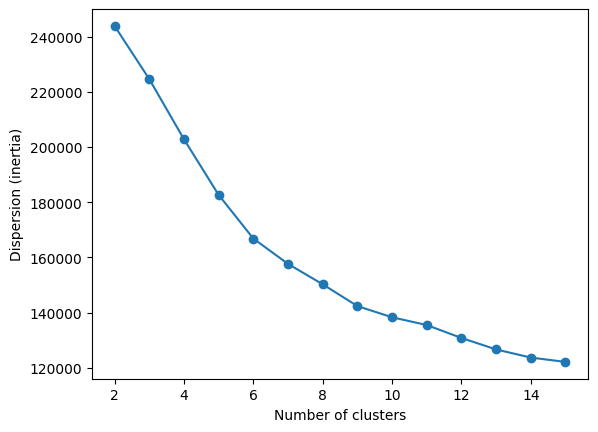

In [7]:
K_range = 15

inertias = []

for k in range(2, K_range+1):
    experimental_kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertias.append(experimental_kmeans.inertia_)

plt.plot(range(2, K_range+1), inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion (inertia)')
plt.show()

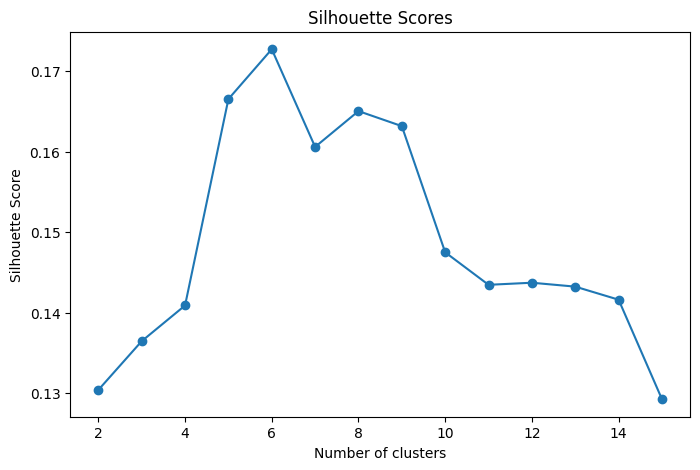

In [8]:
scores = []

for k in range(2,K_range+1):
    experimental_kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = experimental_kmeans.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))
        
plt.figure(figsize=(8, 5))
plt.plot(range(2,K_range+1), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

k=8 | silhouette=0.1688
k=9 | silhouette=0.1773
k=10 | silhouette=0.1749


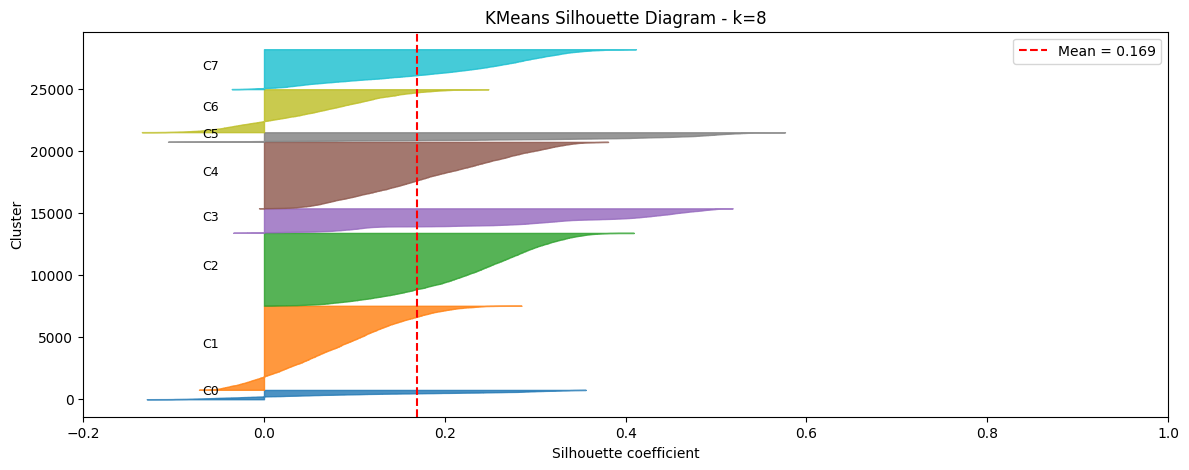

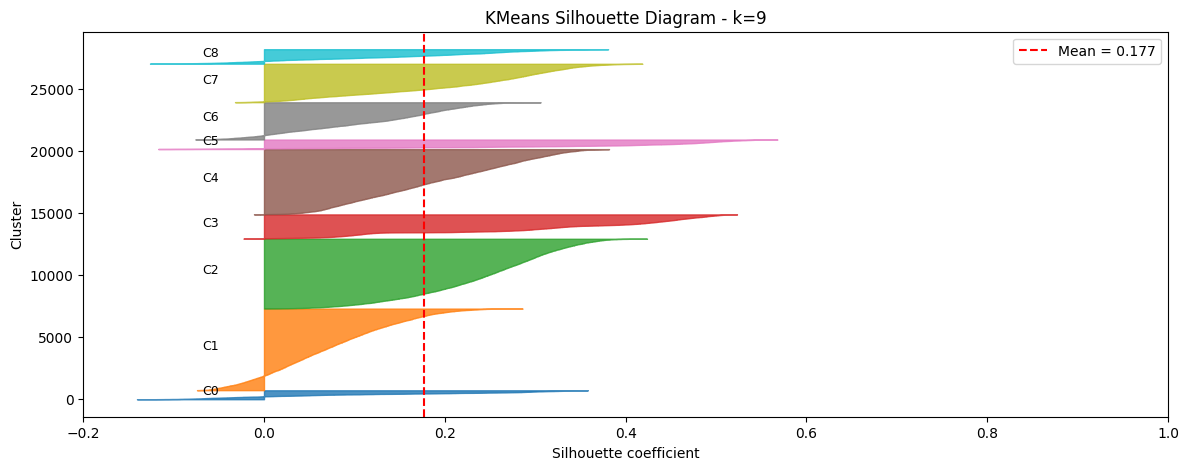

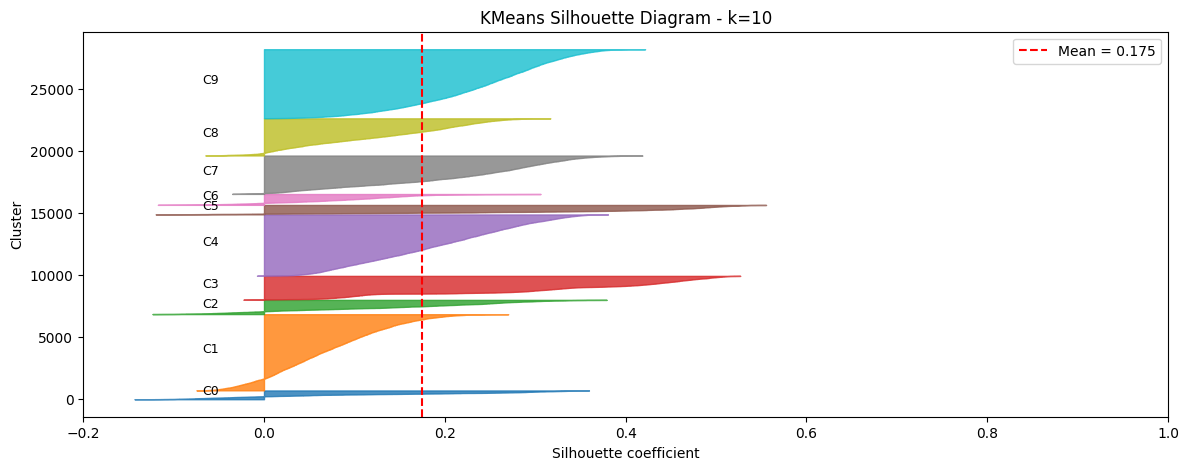

In [ ]:
for k in [8, 9, 10]:
    experimental_kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = experimental_kmeans.fit_predict(X_scaled)

    score = plot_silhouette(
        X_scaled,
        labels,
        title=f"KMeans Silhouette Diagram - k={k}"
    )

    print(f"k={k} | silhouette={score:.4f}")

In [9]:
kmeans = KMeans(n_clusters= 9,random_state=42, n_init='auto').fit(X_scaled)
dataset['cluster_kmeans'] = kmeans.predict(X_scaled)


In [10]:
dataset["cluster_kmeans"].value_counts()

cluster_kmeans
1    5716
8    4397
2    4250
5    4191
6    2722
7    2502
3    1978
0    1354
4     992
Name: count, dtype: int64

In [11]:
X['cluster_kmeans'] = dataset['cluster_kmeans']

In [12]:
X.groupby("cluster_kmeans").mean().T

cluster_kmeans,0,1,2,3,4,5,6,7,8
customer_age,58.987445,64.894157,36.365647,58.257331,63.846774,51.680744,58.565026,57.768585,56.045486
number_complaints,0.844904,0.683870,1.158588,0.858443,3.534274,0.991172,0.752021,1.033573,0.483511
total_children,1.440916,1.722883,1.883059,6.920121,2.689516,1.476974,1.944526,0.595524,1.770071
percentage_of_products_bought_promotion,0.455248,0.253483,0.269163,0.204942,0.314155,0.796877,0.110654,0.259921,0.163544
perc_spend_vegetables,0.061479,0.021497,0.019845,0.023047,0.027925,0.022924,0.161108,0.008418,0.063531
perc_spend_meat_fish,0.180359,0.058890,0.063123,0.079873,0.072847,0.067659,0.013178,0.077786,0.030046
perc_alcohol_drinks,0.494079,0.510263,0.676199,0.643707,0.542305,0.569066,0.478056,0.648206,0.197507
perc_spend_petfood,0.053404,0.012975,0.015807,0.010058,0.018649,0.017005,0.022418,0.013373,0.020271
perc_spend_tech_entertainment,0.135004,0.082363,0.094460,0.152643,0.102040,0.072731,0.158783,0.499285,0.059441
years_tenure,11.439439,15.110217,7.036471,13.397877,12.012097,9.858745,11.338722,8.960432,9.825563


- 0 ??????????
- 1  young adults
- 2 big families
- 3 promootions
- 4 ??????????????'
- 5 veggie
- 6 gamers
- 7 complaints

-0 ?
- 1 young adults
- 2 children
- 3 promotion
- 4 oldest customers ?
- 5
- 6 gamers
- 7 karens
- 8 veggie

In [20]:
X.groupby('cluster_kmeans').median().T

cluster_kmeans,0,1,2,3,4,5,6,7,8
customer_age,60.000000,56.000000,58.000000,34.000000,57.000000,58.000000,58.000000,57.000000,58.000000
years_tenure,11.000000,10.000000,13.000000,9.000000,9.000000,10.000000,13.000000,13.000000,12.000000
number_complaints,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000
total_children,1.000000,1.000000,7.000000,2.000000,0.000000,2.000000,4.000000,1.000000,2.000000
percentage_of_products_bought_promotion,0.429815,0.570014,0.202225,0.433950,0.250995,0.151829,0.228244,0.140462,0.103448
perc_spend_vegetables,0.046895,0.014193,0.020966,0.014827,0.005626,0.086080,0.016327,0.021953,0.135358
perc_spend_meat_fish,0.164714,0.057235,0.072912,0.065302,0.071928,0.013695,0.063299,0.055737,0.008311
perc_spend_petfood,0.047017,0.012971,0.009460,0.017268,0.012336,0.023325,0.009660,0.014115,0.017239
perc_spend_tech_entertainment,0.111104,0.060317,0.142477,0.067885,0.490473,0.047226,0.119204,0.054780,0.148613
distinct_stores_visited,4.000000,5.000000,3.000000,2.000000,1.000000,4.000000,4.000000,2.000000,3.000000


In [ ]:
experimental_hierarchical = AgglomerativeClustering(linkage='ward', distance_threshold=0, n_clusters=None).fit(X_scaled)

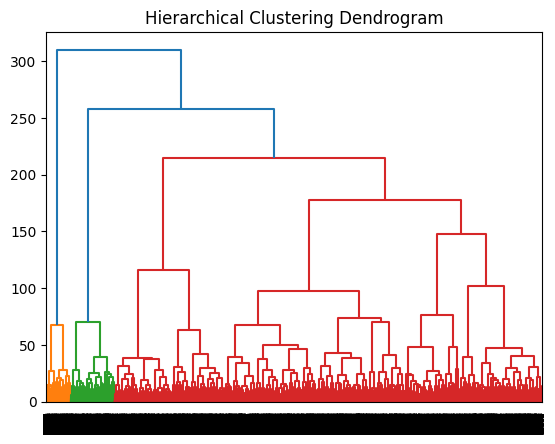

In [13]:
fig, ax = plt.subplots()
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(experimental_hierarchical, truncate_mode="level", p=50)
plt.show()


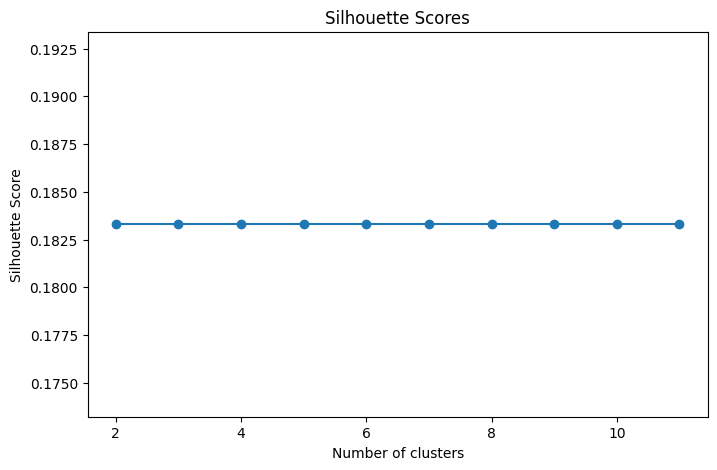

In [ ]:
scores = []

for k in range(2,K_range+1):
    experimental_hierachical = AgglomerativeClustering(n_clusters=k, linkage='ward', random_state = 42, n_init= 10)
    labels = experimental_kmeans.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))
        
plt.figure(figsize=(8, 5))
plt.plot(range(2,K_range+1), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

In [20]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_workflow = Clusteringworkflow(hierarchical)

hierarchical_workflow.fit_and_prediction(dataset, X_scaled)

dataset.head()

NameError: name 'Clusteringworkflow' is not defined

In [18]:
dataset.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'total_children', 'has_children',
       'year_first_transaction', 'distinct_stores_visited',
       'number_complaints', 'typical_hour', 'time_of_day',
       'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'latitude', 'longitude', 'total_trips',
       'total_items_bought', 'average_basket_size', 'max_basket_size',
       'min_basket_size', 'unique_products_bought', 'cluster_kmeans'],
      dtype='str')

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32242 entries, 3 to 40000
Data columns (total 30 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            32242 non-null  object 
 1   customer_gender                          32242 non-null  object 
 2   customer_age                             32242 non-null  int64  
 3   education_level                          32242 non-null  object 
 4   kids_home                                32242 non-null  int64  
 5   teens_home                               32242 non-null  int64  
 6   total_children                           32242 non-null  int64  
 7   has_children                             32242 non-null  int64  
 8   year_first_transaction                   32242 non-null  int64  
 9   distinct_stores_visited                  32242 non-null  int64  
 10  number_complaints                        32242 non-

In [21]:
pd.DataFrame(
    confusion_matrix(
        dataset['cluster_kmeans'],
        dataset['cluster_agglomerativeclustering']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 4)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 4)]
)

KeyError: 'cluster_agglomerativeclustering'

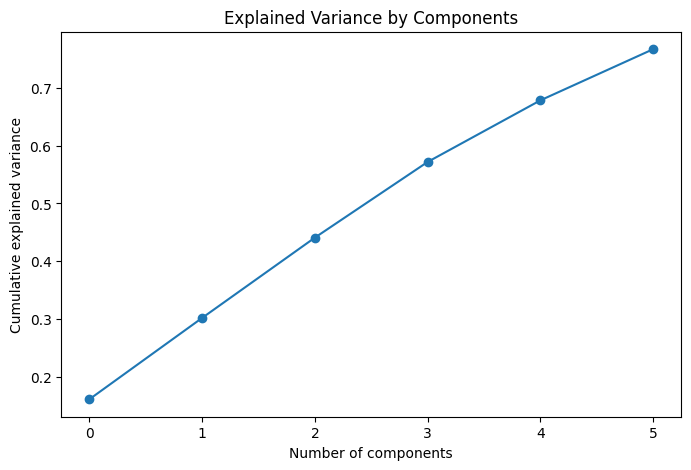

In [257]:
pca = PCA(n_components=6, random_state=42)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Explained Variance by Components')
plt.show()

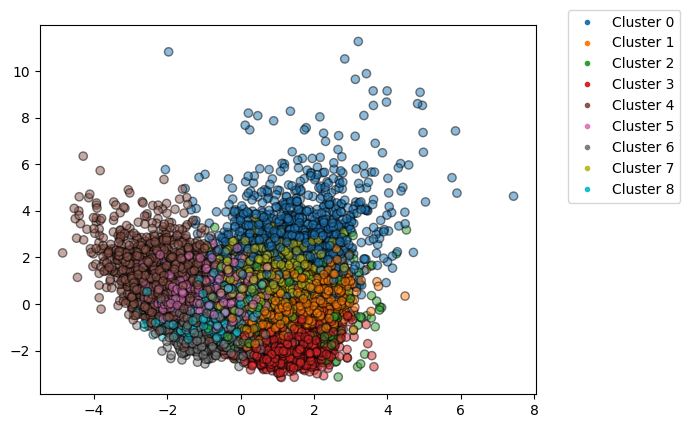

In [258]:
plot_2d_with_classes(dataset['cluster_kmeans'],components)

In [259]:
tsne = TSNE(
    n_components=2,
    perplexity=150,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_transformation = tsne.fit_transform(X_scaled)


c:\Users\laura\Desktop\ML II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


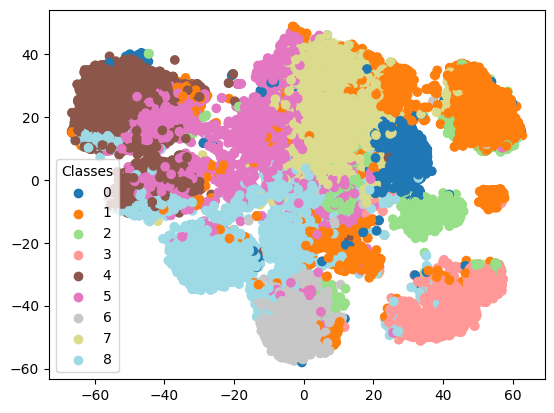

In [260]:
visualize_dimensionality_reduction(tsne_transformation, dataset['cluster_kmeans'])    


In [ ]:
umap = UMAP(n_neighbors=15, min_dist=0.0,metric = 'euclidean', random_state=42)



umap_transformation = umap.fit_transform(X_scaled)

c:\Users\laura\Desktop\ML II\ml_project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\laura\Desktop\ML II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


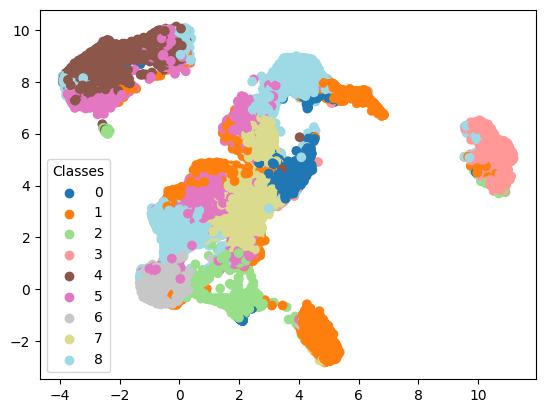

In [262]:
visualize_dimensionality_reduction(umap_transformation, dataset['cluster_kmeans'])